In [3]:
import pandas as pd
import numpy as np

print("Financial Anomaly Detection Model")
print("=================================")

Financial Anomaly Detection Model


In [4]:
# ============================================================
# LOAD FINAL TRAINING AND TESTING DATA
# ============================================================

train_df = pd.read_csv("financial_anomaly_train_final.csv")
test_df = pd.read_csv("financial_anomaly_test_final.csv")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

print("\nTraining dataset:")
display(train_df.head())

print("\nTesting dataset:")
display(test_df.head())

Training dataset shape: (78739, 14)
Testing dataset shape : (20016, 14)

Training dataset:


,work_id,financial_year,sanction_amount,total_disbursed_amount,payment_count,in_progress_payment_count,in_progress_payment_amount,payment_to_sanction_ratio,payment_minus_sanction_amount,average_payment_amount,maximum_payment_amount,minimum_payment_amount,payment_amount_std,payment_duration_days
0,WS/MP620/2024-2025/133166,2024-2025,497185.0,497185.0,1,0,0.0,1.000000,0.0,497185.0,497185.0,497185.0,0.0,0.0
1,WS/MP620/2025-2026/133167,2025-2026,500000.0,0.0,0,0,0.0,0.000000,-500000.0,0.0,0.0,0.0,0.0,0.0
2,WS/MP620/2024-2025/133190,2024-2025,450000.0,0.0,0,0,0.0,0.000000,-450000.0,0.0,0.0,0.0,0.0,0.0
3,WS/MP620/2025-2026/133191,2025-2026,1500000.0,850909.0,1,0,0.0,0.567273,-649091.0,850909.0,850909.0,850909.0,0.0,0.0
4,WS/MP620/2024-2025/133301,2024-2025,398009.0,398009.0,1,0,0.0,1.000000,0.0,398009.0,398009.0,398009.0,0.0,0.0



Testing dataset:


,work_id,financial_year,sanction_amount,total_disbursed_amount,payment_count,in_progress_payment_count,in_progress_payment_amount,payment_to_sanction_ratio,payment_minus_sanction_amount,average_payment_amount,maximum_payment_amount,minimum_payment_amount,payment_amount_std,payment_duration_days
0,WS/MP577/2026-2027/133610,2026-2027,250000.0,0.0,0,0,0.0,0.0,-250000.0,0.0,0.0,0.0,0.0,0.0
1,WS/MP632/2026-2027/134591,2026-2027,96734.0,0.0,0,0,0.0,0.0,-96734.0,0.0,0.0,0.0,0.0,0.0
2,WS/MP18271/2026-2027/135215,2026-2027,1298112.0,0.0,0,0,0.0,0.0,-1298112.0,0.0,0.0,0.0,0.0,0.0
3,WS/MP18271/2026-2027/135216,2026-2027,1077149.0,0.0,0,0,0.0,0.0,-1077149.0,0.0,0.0,0.0,0.0,0.0
4,WS/MP18271/2026-2027/135219,2026-2027,2823486.0,0.0,0,0,0.0,0.0,-2823486.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# ============================================================
# PREPARE FEATURES FOR ISOLATION FOREST
# ============================================================

# These columns identify the work but must NOT be used by the model
metadata_columns = ["work_id", "financial_year"]

# The remaining columns are our 12 ML features
feature_columns = [
    col for col in train_df.columns
    if col not in metadata_columns
]

# Create training and testing feature matrices
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

print("Number of ML features:", len(feature_columns))
print("\nFeatures used by Isolation Forest:")

for i, feature in enumerate(feature_columns, 1):
    print(f"{i}. {feature}")

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

Number of ML features: 12

Features used by Isolation Forest:
1. sanction_amount
2. total_disbursed_amount
3. payment_count
4. in_progress_payment_count
5. in_progress_payment_amount
6. payment_to_sanction_ratio
7. payment_minus_sanction_amount
8. average_payment_amount
9. maximum_payment_amount
10. minimum_payment_amount
11. payment_amount_std
12. payment_duration_days

X_train shape: (78739, 12)
X_test shape : (20016, 12)

Missing values:
X_train: 0
X_test : 0


In [6]:
# ============================================================
# BASELINE ISOLATION FOREST MODEL
# ============================================================

from sklearn.ensemble import IsolationForest

# Create baseline model
baseline_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    max_samples="auto",
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("Training baseline Isolation Forest...")

# Train ONLY on the historical training data
baseline_model.fit(X_train)

print("Training completed successfully.")

Training baseline Isolation Forest...
Training completed successfully.


In [7]:
# ============================================================
# GENERATE ANOMALY SCORES FOR TRAINING DATA
# ============================================================

# sklearn's score_samples:
# higher = more normal
# lower  = more anomalous

train_raw_score = baseline_model.score_samples(X_train)

# Convert so that higher = more anomalous
train_anomaly_score = -train_raw_score

print("Training anomaly scores generated.")

print("\nScore statistics:")
print(pd.Series(train_anomaly_score).describe())

Training anomaly scores generated.

Score statistics:
count    78739.000000
mean         0.394647
std          0.069733
min          0.331141
25%          0.341844
50%          0.382601
75%          0.412537
max          0.831121
dtype: float64


In [8]:
# ============================================================
# BASELINE MODEL PREDICTIONS
# ============================================================

train_prediction = baseline_model.predict(X_train)

# Isolation Forest:
#  1  = normal
# -1  = anomaly

train_anomaly_flag = (train_prediction == -1).astype(int)

print("Normal works :", (train_anomaly_flag == 0).sum())
print("Anomalous works:", (train_anomaly_flag == 1).sum())

print(
    "\nAnomaly percentage:",
    train_anomaly_flag.mean() * 100,
    "%"
)

Normal works : 72259
Anomalous works: 6480

Anomaly percentage: 8.229720976898362 %


In [9]:
# ============================================================
# SCORE THE UNSEEN TEST DATA
# ============================================================

# Generate anomaly scores for unseen test data
test_raw_score = baseline_model.score_samples(X_test)

# Convert so that:
# higher score = more anomalous
test_anomaly_score = -test_raw_score

# Generate Isolation Forest predictions
test_prediction = baseline_model.predict(X_test)

# Convert:
# 0 = normal
# 1 = anomaly
test_anomaly_flag = (test_prediction == -1).astype(int)

print("Test anomaly scores generated successfully.")

print("\nTest score statistics:")
print(pd.Series(test_anomaly_score).describe())

print("\nTest results:")
print("Normal works    :", (test_anomaly_flag == 0).sum())
print("Anomalous works :", (test_anomaly_flag == 1).sum())

print(
    "\nTest anomaly percentage:",
    round(test_anomaly_flag.mean() * 100, 2),
    "%"
)

Test anomaly scores generated successfully.

Test score statistics:
count    20016.000000
mean         0.412769
std          0.062917
min          0.331320
25%          0.387197
50%          0.395639
75%          0.421637
max          0.813908
dtype: float64

Test results:
Normal works    : 18132
Anomalous works : 1884

Test anomaly percentage: 9.41 %


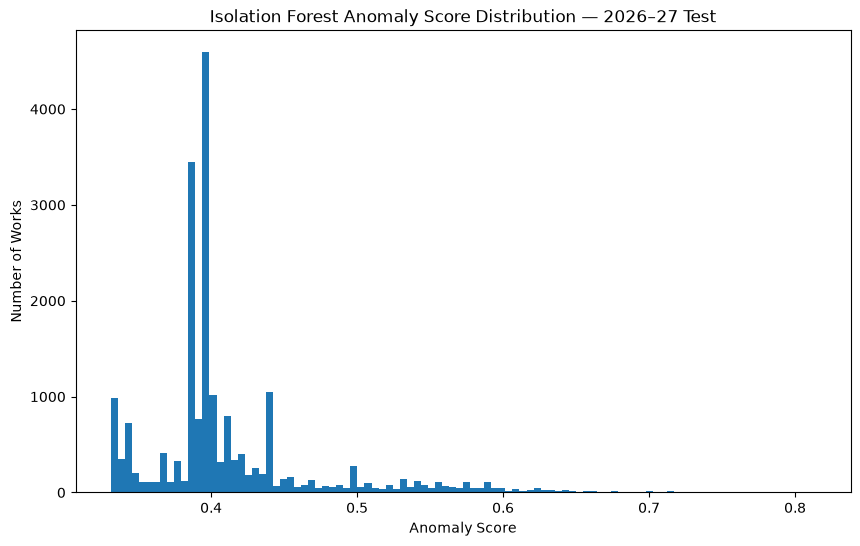

In [10]:
# ============================================================
# VALIDATION 1 — ANOMALY SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    test_anomaly_score,
    bins=100
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Works")
plt.title("Isolation Forest Anomaly Score Distribution — 2026–27 Test")

plt.show()

In [11]:
# ============================================================
# TEST SCORE PERCENTILES
# ============================================================

test_score_series = pd.Series(test_anomaly_score)

percentiles = [90, 95, 97, 98, 99, 99.5, 99.9]

percentile_table = pd.DataFrame({
    "percentile": percentiles,
    "anomaly_score": [
        np.percentile(test_anomaly_score, p)
        for p in percentiles
    ]
})

display(percentile_table)

,percentile,anomaly_score
0,90.0,0.496595
1,95.0,0.554778
2,97.0,0.587208
3,98.0,0.606425
4,99.0,0.641655
5,99.5,0.690264
6,99.9,0.759702


In [12]:
# ============================================================
# VALIDATION 2 — CREATE SCORED TEST DATASET
# ============================================================

test_results = test_df.copy()

# Add model outputs
test_results["anomaly_score"] = test_anomaly_score
test_results["baseline_anomaly"] = test_anomaly_flag

# Sort from most anomalous to least anomalous
test_results = test_results.sort_values(
    "anomaly_score",
    ascending=False
).reset_index(drop=True)

print("Scored test dataset created.")
print("Rows:", len(test_results))

display(test_results.head(10))

Scored test dataset created.
Rows: 20016


,work_id,financial_year,sanction_amount,total_disbursed_amount,payment_count,in_progress_payment_count,in_progress_payment_amount,payment_to_sanction_ratio,payment_minus_sanction_amount,average_payment_amount,maximum_payment_amount,minimum_payment_amount,payment_amount_std,payment_duration_days,anomaly_score,baseline_anomaly
0,WS/MP18435/2026-2027/255473,2026-2027,15000000.0,8112106.0,3,2,17588.0,0.540807,-6887894.0,2.704035e+06,8094518.0,168.0,4.668303e+06,12.0,0.813908,1
1,WS/MP507/2026-2027/290535,2026-2027,49740000.0,35321457.0,8,0,0.0,0.710122,-14418543.0,4.415182e+06,5651433.0,3532146.0,6.865257e+05,0.0,0.803459,1
2,WS/MP188/2026-2027/179557,2026-2027,19933000.0,2710610.0,1,1,2710610.0,0.135986,-17222390.0,2.710610e+06,2710610.0,2710610.0,0.000000e+00,0.0,0.802660,1
3,WS/MP888/2026-2027/251789,2026-2027,9850044.0,9710913.0,1,1,9710913.0,0.985875,-139131.0,9.710913e+06,9710913.0,9710913.0,0.000000e+00,0.0,0.798889,1
4,WS/MP18368/2026-2027/296403,2026-2027,23047200.0,13780800.0,4,0,0.0,0.597938,-9266400.0,3.445200e+06,4276800.0,2376000.0,8.115585e+05,0.0,0.791641,1
5,WS/MP492/2026-2027/294027,2026-2027,14533200.0,8580000.0,1,0,0.0,0.590372,-5953200.0,8.580000e+06,8580000.0,8580000.0,0.000000e+00,0.0,0.790830,1
6,WS/MP092/2026-2027/305015,2026-2027,20000000.0,15000000.0,1,0,0.0,0.750000,-5000000.0,1.500000e+07,15000000.0,15000000.0,0.000000e+00,0.0,0.788855,1
7,WS/MP092/2026-2027/305016,2026-2027,20000000.0,15000000.0,1,0,0.0,0.750000,-5000000.0,1.500000e+07,15000000.0,15000000.0,0.000000e+00,0.0,0.788855,1
8,WS/MP18421/2026-2027/290263,2026-2027,19900000.0,14925000.0,1,0,0.0,0.750000,-4975000.0,1.492500e+07,14925000.0,14925000.0,0.000000e+00,0.0,0.788855,1
9,WS/MP18382/2026-2027/220474,2026-2027,13628575.0,7137950.0,1,0,0.0,0.523749,-6490625.0,7.137950e+06,7137950.0,7137950.0,0.000000e+00,0.0,0.788541,1


In [13]:
# EXPORT FINANCIAL ANOMALY RESULTS — FY 2026-27

output_file = "mplads_anomaly_results_2026_27.csv"

test_results.to_csv(output_file, index=False)

print("Exported:", output_file)
print("Rows:", len(test_results))
print("Columns:", len(test_results.columns))

Exported: mplads_anomaly_results_2026_27.csv
Rows: 20016
Columns: 16


In [11]:
# ============================================================
# COMPARE FINANCIAL CHARACTERISTICS BY SCORE GROUP
# ============================================================

comparison_features = [
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "in_progress_payment_count",
    "in_progress_payment_amount",
    "payment_to_sanction_ratio",
    "payment_minus_sanction_amount",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

# Define score groups
test_results["score_group"] = pd.cut(
    test_results["anomaly_score"],
    bins=[
        -np.inf,
        np.percentile(test_anomaly_score, 90),
        np.percentile(test_anomaly_score, 95),
        np.percentile(test_anomaly_score, 99),
        np.inf
    ],
    labels=[
        "Bottom 90%",
        "90–95%",
        "95–99%",
        "Top 1%"
    ]
)

group_summary = (
    test_results
    .groupby("score_group", observed=True)[comparison_features]
    .median()
)

display(group_summary.T)

score_group,Bottom 90%,90–95%,95–99%,Top 1%
sanction_amount,365800.0,1700000.0,1000000.00000,4000000.00
total_disbursed_amount,0.0,0.0,349650.00000,2258568.00
payment_count,0.0,0.0,1.00000,1.00
in_progress_payment_count,0.0,0.0,1.00000,0.00
in_progress_payment_amount,0.0,0.0,121002.00000,0.00
payment_to_sanction_ratio,0.0,0.0,0.74999,0.75
payment_minus_sanction_amount,-220827.0,-1492500.0,-150000.00000,-400007.00
average_payment_amount,0.0,0.0,299938.00000,1918541.00
maximum_payment_amount,0.0,0.0,339844.00000,2195066.00
minimum_payment_amount,0.0,0.0,250000.00000,1711944.00


In [12]:
# ============================================================
# TOP 1% VS BOTTOM 90% — RELATIVE DIFFERENCE
# ============================================================

bottom_90 = test_results[
    test_results["score_group"] == "Bottom 90%"
]

top_1 = test_results[
    test_results["score_group"] == "Top 1%"
]

relative_comparison = pd.DataFrame({
    "bottom_90_median": bottom_90[comparison_features].median(),
    "top_1_median": top_1[comparison_features].median()
})

relative_comparison["top1_vs_bottom_ratio"] = (
    relative_comparison["top_1_median"]
    /
    relative_comparison["bottom_90_median"].replace(0, np.nan)
)

display(
    relative_comparison.sort_values(
        "top1_vs_bottom_ratio",
        ascending=False
    )
)

,bottom_90_median,top_1_median,top1_vs_bottom_ratio
sanction_amount,365800.0,4000000.00,10.934937
payment_minus_sanction_amount,-220827.0,-400007.00,1.811404
total_disbursed_amount,0.0,2258568.00,NaN
payment_count,0.0,1.00,NaN
in_progress_payment_count,0.0,0.00,NaN
in_progress_payment_amount,0.0,0.00,NaN
payment_to_sanction_ratio,0.0,0.75,NaN
average_payment_amount,0.0,1918541.00,NaN
maximum_payment_amount,0.0,2195066.00,NaN
minimum_payment_amount,0.0,1711944.00,NaN


In [13]:
# ============================================================
# VALIDATION 3 — TOP ANOMALY INSPECTION
# ============================================================

top_50 = test_results.head(50).copy()

inspection_columns = [
    "work_id",
    "financial_year",
    "anomaly_score",
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "in_progress_payment_count",
    "in_progress_payment_amount",
    "payment_to_sanction_ratio",
    "payment_minus_sanction_amount",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

display(
    top_50[inspection_columns]
)

,work_id,financial_year,anomaly_score,sanction_amount,total_disbursed_amount,payment_count,in_progress_payment_count,in_progress_payment_amount,payment_to_sanction_ratio,payment_minus_sanction_amount,average_payment_amount,maximum_payment_amount,minimum_payment_amount,payment_amount_std,payment_duration_days
0,WS/MP18435/2026-2027/255473,2026-2027,0.813908,15000000.0,8112106.0,3,2,17588.0,0.540807,-6887894.0,2.704035e+06,8094518.0,168.0,4.668303e+06,12.0
1,WS/MP507/2026-2027/290535,2026-2027,0.803459,49740000.0,35321457.0,8,0,0.0,0.710122,-14418543.0,4.415182e+06,5651433.0,3532146.0,6.865257e+05,0.0
2,WS/MP188/2026-2027/179557,2026-2027,0.802660,19933000.0,2710610.0,1,1,2710610.0,0.135986,-17222390.0,2.710610e+06,2710610.0,2710610.0,0.000000e+00,0.0
3,WS/MP888/2026-2027/251789,2026-2027,0.798889,9850044.0,9710913.0,1,1,9710913.0,0.985875,-139131.0,9.710913e+06,9710913.0,9710913.0,0.000000e+00,0.0
4,WS/MP18368/2026-2027/296403,2026-2027,0.791641,23047200.0,13780800.0,4,0,0.0,0.597938,-9266400.0,3.445200e+06,4276800.0,2376000.0,8.115585e+05,0.0
5,WS/MP492/2026-2027/294027,2026-2027,0.790830,14533200.0,8580000.0,1,0,0.0,0.590372,-5953200.0,8.580000e+06,8580000.0,8580000.0,0.000000e+00,0.0
6,WS/MP092/2026-2027/305015,2026-2027,0.788855,20000000.0,15000000.0,1,0,0.0,0.750000,-5000000.0,1.500000e+07,15000000.0,15000000.0,0.000000e+00,0.0
7,WS/MP092/2026-2027/305016,2026-2027,0.788855,20000000.0,15000000.0,1,0,0.0,0.750000,-5000000.0,1.500000e+07,15000000.0,15000000.0,0.000000e+00,0.0
8,WS/MP18421/2026-2027/290263,2026-2027,0.788855,19900000.0,14925000.0,1,0,0.0,0.750000,-4975000.0,1.492500e+07,14925000.0,14925000.0,0.000000e+00,0.0
9,WS/MP18382/2026-2027/220474,2026-2027,0.788541,13628575.0,7137950.0,1,0,0.0,0.523749,-6490625.0,7.137950e+06,7137950.0,7137950.0,0.000000e+00,0.0


In [14]:
# ============================================================
# PERCENTILE POSITION OF FINANCIAL VALUES
# ============================================================

percentile_features = [
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

for feature in percentile_features:
    rank = test_results[feature].rank(
        pct=True,
        method="average"
    )
    
    test_results[feature + "_percentile"] = rank * 100

print("Percentile features calculated.")

Percentile features calculated.


In [15]:
# ============================================================
# TOP 20 ANOMALIES WITH PERCENTILE INFORMATION
# ============================================================

top_20 = test_results.head(20)

percentile_columns = [
    "work_id",
    "anomaly_score",
    "sanction_amount",
    "sanction_amount_percentile",
    "total_disbursed_amount",
    "total_disbursed_amount_percentile",
    "payment_count",
    "payment_count_percentile",
    "average_payment_amount",
    "average_payment_amount_percentile",
    "maximum_payment_amount",
    "maximum_payment_amount_percentile",
    "payment_duration_days",
    "payment_duration_days_percentile"
]

display(top_20[percentile_columns])

,work_id,anomaly_score,sanction_amount,sanction_amount_percentile,total_disbursed_amount,total_disbursed_amount_percentile,payment_count,payment_count_percentile,average_payment_amount,average_payment_amount_percentile,maximum_payment_amount,maximum_payment_amount_percentile,payment_duration_days,payment_duration_days_percentile
0,WS/MP18435/2026-2027/255473,0.813908,15000000.0,99.922562,8112106.0,99.880096,3,99.020783,2.704035e+06,99.545364,8094518.0,99.925060,12.0,98.298861
1,WS/MP507/2026-2027/290535,0.803459,49740000.0,100.000000,35321457.0,100.000000,8,99.747702,4.415182e+06,99.800160,5651433.0,99.885092,0.0,48.988309
2,WS/MP188/2026-2027/179557,0.802660,19933000.0,99.945044,2710610.0,99.455436,1,80.925260,2.710610e+06,99.550360,2710610.0,99.495404,0.0,48.988309
3,WS/MP888/2026-2027/251789,0.798889,9850044.0,99.840128,9710913.0,99.915068,1,80.925260,9.710913e+06,99.955036,9710913.0,99.955036,0.0,48.988309
4,WS/MP18368/2026-2027/296403,0.791641,23047200.0,99.970024,13780800.0,99.945044,4,99.273082,3.445200e+06,99.715228,4276800.0,99.775180,0.0,48.988309
5,WS/MP492/2026-2027/294027,0.790830,14533200.0,99.910072,8580000.0,99.890088,1,80.925260,8.580000e+06,99.930056,8580000.0,99.930056,0.0,48.988309
6,WS/MP092/2026-2027/305015,0.788855,20000000.0,99.952538,15000000.0,99.962530,1,80.925260,1.500000e+07,99.987510,15000000.0,99.987510,0.0,48.988309
7,WS/MP092/2026-2027/305016,0.788855,20000000.0,99.952538,15000000.0,99.962530,1,80.925260,1.500000e+07,99.987510,15000000.0,99.987510,0.0,48.988309
8,WS/MP18421/2026-2027/290263,0.788855,19900000.0,99.940048,14925000.0,99.955036,1,80.925260,1.492500e+07,99.980016,14925000.0,99.980016,0.0,48.988309
9,WS/MP18382/2026-2027/220474,0.788541,13628575.0,99.890088,7137950.0,99.855116,1,80.925260,7.137950e+06,99.910072,7137950.0,99.905076,0.0,48.988309


In [17]:
# ============================================================
# VALIDATION 4 — DOMAIN / FINANCIAL CONSISTENCY CHECKS
# ============================================================

# Rule 1:
# Total disbursed amount should normally not exceed
# the sanctioned amount.
test_results["rule_over_disbursement"] = (
    test_results["total_disbursed_amount"]
    > test_results["sanction_amount"]
)

# Rule 2:
# Payment-to-sanction ratio should normally not exceed 1.
test_results["rule_payment_exceeds_sanction"] = (
    test_results["payment_to_sanction_ratio"] > 1
)

# Rule 3:
# Negative payment-minus-sanction means payments are below
# the sanctioned amount.
#
# This is NOT a violation.
# We are simply measuring unusual/important cases.
test_results["payment_below_sanction"] = (
    test_results["payment_minus_sanction_amount"] < 0
)

print("Domain/rule checks completed.\n")

print(
    "Works where disbursed amount > sanctioned amount:",
    test_results["rule_over_disbursement"].sum()
)

print(
    "Works where payment-to-sanction ratio > 1:",
    test_results["rule_payment_exceeds_sanction"].sum()
)

print(
    "Works where payment is below sanction:",
    test_results["payment_below_sanction"].sum()
)

Domain/rule checks completed.

Works where disbursed amount > sanctioned amount: 0
Works where payment-to-sanction ratio > 1: 0
Works where payment is below sanction: 17878


In [18]:
# ============================================================
# MODEL ANOMALIES VS DOMAIN RULES
# ============================================================

rule_columns = [
    "rule_over_disbursement",
    "rule_payment_exceeds_sanction"
]

rule_summary = pd.DataFrame({
    "total_works": test_results[rule_columns].sum(),
    "among_model_anomalies": [
        test_results.loc[
            test_results["baseline_anomaly"] == 1,
            col
        ].sum()
        for col in rule_columns
    ]
})

rule_summary["percentage_of_all_works"] = (
    rule_summary["total_works"]
    / len(test_results)
    * 100
)

rule_summary["percentage_among_model_anomalies"] = (
    rule_summary["among_model_anomalies"]
    / test_results["baseline_anomaly"].sum()
    * 100
)

display(rule_summary)

,total_works,among_model_anomalies,percentage_of_all_works,percentage_among_model_anomalies
rule_over_disbursement,0,0,0.0,0.0
rule_payment_exceeds_sanction,0,0,0.0,0.0


In [19]:
# ============================================================
# STABILITY TEST — MULTIPLE ISOLATION FOREST RUNS
# ============================================================

from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

seeds = [42, 52, 62, 72, 82]

stability_predictions = []

for seed in seeds:

    model = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train)

    pred = model.predict(X_test)

    # 1 = anomaly, 0 = normal
    anomaly_flag = (pred == -1).astype(int)

    stability_predictions.append(anomaly_flag)

# Combine all runs
stability_matrix = pd.DataFrame(
    np.array(stability_predictions).T,
    columns=[f"seed_{s}" for s in seeds]
)

# Number of runs in which each work was anomalous
stability_matrix["anomaly_runs"] = stability_matrix.sum(axis=1)

# Percentage of runs
stability_matrix["stability_percentage"] = (
    stability_matrix["anomaly_runs"]
    / len(seeds)
    * 100
)

print("Stability testing completed.")
print()

print("Total test works:", len(stability_matrix))

print("\nAnomaly counts by run:")
for seed in seeds:
    print(
        f"Seed {seed}:",
        stability_matrix[f"seed_{seed}"].sum()
    )

print("\nStability distribution:")
display(
    stability_matrix["stability_percentage"]
    .value_counts()
    .sort_index()
)

Stability testing completed.

Total test works: 20016

Anomaly counts by run:
Seed 42: 1884
Seed 52: 1704
Seed 62: 1727
Seed 72: 1862
Seed 82: 1785

Stability distribution:


stability_percentage
0.0      18092
20.0        38
40.0       115
60.0        44
80.0        73
100.0     1654
Name: count, dtype: int64

In [20]:
# ============================================================
# IDENTIFY STABLE ANOMALIES
# ============================================================

stable_anomalies = stability_matrix[
    stability_matrix["stability_percentage"] >= 80
].copy()

very_stable_anomalies = stability_matrix[
    stability_matrix["stability_percentage"] == 100
].copy()

print(
    "Anomalies appearing in >= 80% of runs:",
    len(stable_anomalies)
)

print(
    "Anomalies appearing in 100% of runs:",
    len(very_stable_anomalies)
)

print("\nStability distribution:")
display(
    stability_matrix["stability_percentage"]
    .value_counts()
    .sort_index()
)

Anomalies appearing in >= 80% of runs: 1727
Anomalies appearing in 100% of runs: 1654

Stability distribution:


stability_percentage
0.0      18092
20.0        38
40.0       115
60.0        44
80.0        73
100.0     1654
Name: count, dtype: int64

In [21]:
# ============================================================
# FEATURE SENSITIVITY / IMPORTANCE TEST
# ============================================================

from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

# Use a sample so this test remains reasonably fast
np.random.seed(42)

sample_size = min(5000, len(X_test))
sample_indices = np.random.choice(
    len(X_test),
    size=sample_size,
    replace=False
)

X_sample = X_test.iloc[sample_indices].copy()

# Baseline scores
baseline_scores = baseline_model.score_samples(X_sample)

# Convert sklearn score so higher = more anomalous
baseline_anomaly_scores = -baseline_scores

feature_importance = []

for feature in X_sample.columns:

    score_changes = []

    for repeat in range(2):

        X_permuted = X_sample.copy()

        # Shuffle only this feature
        X_permuted[feature] = np.random.permutation(
            X_permuted[feature].values
        )

        permuted_scores = baseline_model.score_samples(
            X_permuted
        )

        permuted_anomaly_scores = -permuted_scores

        # Average absolute change
        change = np.mean(
            np.abs(
                baseline_anomaly_scores
                - permuted_anomaly_scores
            )
        )

        score_changes.append(change)

    feature_importance.append({
        "feature": feature,
        "mean_score_change": np.mean(score_changes)
    })

feature_importance_df = pd.DataFrame(
    feature_importance
).sort_values(
    "mean_score_change",
    ascending=False
).reset_index(drop=True)

print("Feature sensitivity analysis completed.\n")

display(feature_importance_df)

Feature sensitivity analysis completed.



,feature,mean_score_change
0,payment_minus_sanction_amount,0.022754
1,payment_to_sanction_ratio,0.019470
2,sanction_amount,0.012546
3,average_payment_amount,0.010440
4,minimum_payment_amount,0.009213
5,maximum_payment_amount,0.008474
6,in_progress_payment_count,0.008227
7,total_disbursed_amount,0.007452
8,in_progress_payment_amount,0.005122
9,payment_count,0.004852


In [22]:
# ============================================================
# STABLE ANOMALY IDENTIFICATION
# ============================================================

# Add stability information to the scored test dataset
test_results["stability_percentage"] = (
    stability_matrix["stability_percentage"].values
)

test_results["anomaly_runs"] = (
    stability_matrix["anomaly_runs"].values
)

# Sort by anomaly score
stable_top_anomalies = test_results[
    test_results["stability_percentage"] >= 80
].sort_values(
    "anomaly_score",
    ascending=False
)

print(
    "Stable anomalies (>=80% of runs):",
    len(stable_top_anomalies)
)

print("\nTop 25 stable anomalies:")

display(
    stable_top_anomalies[
        [
            "work_id",
            "anomaly_score",
            "stability_percentage",
            "sanction_amount",
            "total_disbursed_amount",
            "payment_count",
            "in_progress_payment_count",
            "in_progress_payment_amount",
            "payment_to_sanction_ratio",
            "payment_minus_sanction_amount",
            "average_payment_amount",
            "maximum_payment_amount",
            "minimum_payment_amount",
            "payment_amount_std",
            "payment_duration_days"
        ]
    ].head(25)
)

Stable anomalies (>=80% of runs): 1727

Top 25 stable anomalies:


,work_id,anomaly_score,stability_percentage,sanction_amount,total_disbursed_amount,payment_count,in_progress_payment_count,in_progress_payment_amount,payment_to_sanction_ratio,payment_minus_sanction_amount,average_payment_amount,maximum_payment_amount,minimum_payment_amount,payment_amount_std,payment_duration_days
4,WS/MP18368/2026-2027/296403,0.791641,100.0,23047200.0,13780800.0,4,0,0.0,0.597938,-9266400.0,3.445200e+06,4276800.0,2376000.0,8.115585e+05,0.0
5,WS/MP492/2026-2027/294027,0.790830,100.0,14533200.0,8580000.0,1,0,0.0,0.590372,-5953200.0,8.580000e+06,8580000.0,8580000.0,0.000000e+00,0.0
6,WS/MP092/2026-2027/305015,0.788855,100.0,20000000.0,15000000.0,1,0,0.0,0.750000,-5000000.0,1.500000e+07,15000000.0,15000000.0,0.000000e+00,0.0
14,WS/MP18391/2026-2027/283805,0.773615,100.0,9800000.0,6800000.0,1,0,0.0,0.693878,-3000000.0,6.800000e+06,6800000.0,6800000.0,0.000000e+00,0.0
18,WS/MP492/2026-2027/282269,0.761376,100.0,31200000.0,31200000.0,7,0,0.0,1.000000,0.0,4.457143e+06,5241600.0,3244800.0,6.513328e+05,16.0
20,WS/MP203/2026-2027/284964,0.759704,100.0,28512000.0,28512000.0,7,0,0.0,1.000000,0.0,4.073143e+06,4989600.0,3326400.0,5.726862e+05,27.0
41,WS/MP18095/2026-2027/246711,0.727769,100.0,1841700.0,1676142.0,2,2,1676142.0,0.910106,-165558.0,8.380710e+05,1601555.0,74587.0,1.079729e+06,0.0
48,WS/MP831/2026-2027/302091,0.718734,100.0,2600000.0,1560000.0,1,1,1560000.0,0.600000,-1040000.0,1.560000e+06,1560000.0,1560000.0,0.000000e+00,0.0
49,WS/MP18116/2026-2027/232150,0.718505,100.0,2500000.0,2447691.0,1,1,2447691.0,0.979076,-52309.0,2.447691e+06,2447691.0,2447691.0,0.000000e+00,0.0
50,WS/MP756/2026-2027/171038,0.718488,100.0,4500000.0,4356128.0,2,0,0.0,0.968028,-143872.0,2.178064e+06,4256261.0,99867.0,2.939014e+06,48.0


In [23]:
# ============================================================
# PERCENTILE-BASED ANOMALY EXPLANATION
# ============================================================

explanation_features = [
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "in_progress_payment_count",
    "in_progress_payment_amount",
    "payment_to_sanction_ratio",
    "payment_minus_sanction_amount",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

# Training reference distributions
train_reference = train_df[explanation_features].copy()

# Create percentile ranks for test values
for feature in explanation_features:

    reference = train_reference[feature].dropna().sort_values()

    test_results[f"{feature}_percentile"] = (
        test_results[feature]
        .apply(
            lambda x: (
                (reference <= x).mean() * 100
                if pd.notna(x)
                else np.nan
            )
        )
    )

print("Feature percentile explanations created.")

Feature percentile explanations created.


In [24]:
# ============================================================
# EXPLANATION FOR TOP ANOMALOUS WORKS
# ============================================================

top_work = test_results[
    test_results["stability_percentage"] >= 80
].sort_values(
    "anomaly_score",
    ascending=False
).head(10)

for _, row in top_work.iterrows():

    print("\n" + "=" * 70)
    print("WORK ID:", row["work_id"])
    print("ANOMALY SCORE:", round(row["anomaly_score"], 6))
    print(
        "STABILITY:",
        row["stability_percentage"],
        "%"
    )

    print("\nMost unusual financial characteristics:")

    explanation = []

    for feature in explanation_features:

        percentile = row[f"{feature}_percentile"]

        if pd.notna(percentile):

            # Distance from the center of the distribution
            unusualness = abs(percentile - 50)

            explanation.append(
                (
                    feature,
                    percentile,
                    unusualness
                )
            )

    explanation = sorted(
        explanation,
        key=lambda x: x[2],
        reverse=True
    )

    for feature, percentile, unusualness in explanation[:5]:

        print(
            f"  {feature}: "
            f"{row[feature]:,.2f} "
            f"({percentile:.2f} percentile)"
        )


WORK ID: WS/MP18368/2026-2027/296403
ANOMALY SCORE: 0.791641
STABILITY: 100.0 %

Most unusual financial characteristics:
  sanction_amount: 23,047,200.00 (99.97 percentile)
  payment_minus_sanction_amount: -9,266,400.00 (0.05 percentile)
  total_disbursed_amount: 13,780,800.00 (99.92 percentile)
  maximum_payment_amount: 4,276,800.00 (99.62 percentile)
  average_payment_amount: 3,445,200.00 (99.57 percentile)

WORK ID: WS/MP492/2026-2027/294027
ANOMALY SCORE: 0.79083
STABILITY: 100.0 %

Most unusual financial characteristics:
  minimum_payment_amount: 8,580,000.00 (99.96 percentile)
  average_payment_amount: 8,580,000.00 (99.96 percentile)
  maximum_payment_amount: 8,580,000.00 (99.94 percentile)
  payment_minus_sanction_amount: -5,953,200.00 (0.10 percentile)
  sanction_amount: 14,533,200.00 (99.90 percentile)

WORK ID: WS/MP092/2026-2027/305015
ANOMALY SCORE: 0.788855
STABILITY: 100.0 %

Most unusual financial characteristics:
  average_payment_amount: 15,000,000.00 (99.99 percentil

In [25]:
# ============================================================
# FEATURE ABLATION TEST
# Does the model remain stable without the two derived features?
# ============================================================

from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Full feature set
# ------------------------------------------------------------

full_features = [
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "in_progress_payment_count",
    "in_progress_payment_amount",
    "payment_to_sanction_ratio",
    "payment_minus_sanction_amount",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

# ------------------------------------------------------------
# Reduced feature set
# Remove mathematically derived features
# ------------------------------------------------------------

reduced_features = [
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "in_progress_payment_count",
    "in_progress_payment_amount",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

print("Full feature count:", len(full_features))
print("Reduced feature count:", len(reduced_features))

# ------------------------------------------------------------
# Train two models using identical settings
# ------------------------------------------------------------

ablation_results = []

for seed in [42, 52, 62, 72, 82]:

    # Full model
    full_model = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=seed,
        n_jobs=-1
    )

    full_model.fit(
        train_df[full_features]
    )

    full_pred = full_model.predict(
        test_df[full_features]
    )

    full_anomaly = (full_pred == -1).astype(int)

    # Reduced model
    reduced_model = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=seed,
        n_jobs=-1
    )

    reduced_model.fit(
        train_df[reduced_features]
    )

    reduced_pred = reduced_model.predict(
        test_df[reduced_features]
    )

    reduced_anomaly = (reduced_pred == -1).astype(int)

    # Agreement between models
    agreement = np.mean(
        full_anomaly == reduced_anomaly
    )

    ablation_results.append({
        "seed": seed,
        "full_anomalies": full_anomaly.sum(),
        "reduced_anomalies": reduced_anomaly.sum(),
        "prediction_agreement": agreement
    })

ablation_results = pd.DataFrame(ablation_results)

print("\nAblation test results:")
display(ablation_results)

print(
    "\nMean prediction agreement:",
    round(
        ablation_results["prediction_agreement"].mean() * 100,
        2
    ),
    "%"
)

Full feature count: 12
Reduced feature count: 10

Ablation test results:


,seed,full_anomalies,reduced_anomalies,prediction_agreement
0,42,1884,1230,0.963729
1,52,1704,1179,0.962080
2,62,1727,1199,0.958833
3,72,1862,1268,0.961431
4,82,1785,1191,0.957634



Mean prediction agreement: 96.07 %


In [26]:
# ============================================================
# TOP ANOMALY OVERLAP TEST
# ============================================================

# Train final comparison models with one fixed seed
full_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

reduced_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

full_model.fit(train_df[full_features])
reduced_model.fit(train_df[reduced_features])

# Higher = more anomalous
full_scores = -full_model.score_samples(
    test_df[full_features]
)

reduced_scores = -reduced_model.score_samples(
    test_df[reduced_features]
)

# Top 1% from each model
top_n = max(1, int(len(test_df) * 0.01))

full_top_indices = set(
    np.argsort(full_scores)[-top_n:]
)

reduced_top_indices = set(
    np.argsort(reduced_scores)[-top_n:]
)

overlap = (
    len(full_top_indices & reduced_top_indices)
    / len(full_top_indices)
    * 100
)

print("Top 1% works in full model:", len(full_top_indices))
print("Top 1% works in reduced model:", len(reduced_top_indices))
print(
    "Top 1% overlap:",
    round(overlap, 2),
    "%"
)

Top 1% works in full model: 200
Top 1% works in reduced model: 200
Top 1% overlap: 83.0 %


In [27]:
# ============================================================
# FINAL RISK TIERING
# ============================================================

# Use the previously calculated test anomaly scores

risk_bins = [
    -np.inf,
    0.496595,
    0.554778,
    0.606425,
    0.690264,
    np.inf
]

risk_labels = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "VERY_HIGH",
    "CRITICAL"
]

test_results["risk_level"] = pd.cut(
    test_results["anomaly_score"],
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True
)

print("Final risk classification created.\n")

risk_summary = (
    test_results["risk_level"]
    .value_counts()
    .reindex(risk_labels)
    .fillna(0)
    .astype(int)
    .to_frame("work_count")
)

risk_summary["percentage"] = (
    risk_summary["work_count"]
    / len(test_results)
    * 100
)

display(risk_summary)

Final risk classification created.



,work_count,percentage
risk_level,,
LOW,18025,90.052958
MEDIUM,913,4.561351
HIGH,677,3.382294
VERY_HIGH,300,1.498801
CRITICAL,101,0.504596


In [28]:
# ============================================================
# FINAL HIGH-RISK WORKS
# ============================================================

final_high_risk = test_results[
    test_results["risk_level"].isin(
        ["HIGH", "VERY_HIGH", "CRITICAL"]
    )
].sort_values(
    "anomaly_score",
    ascending=False
)

print(
    "High-risk and above works:",
    len(final_high_risk)
)

display(
    final_high_risk[
        [
            "work_id",
            "financial_year",
            "anomaly_score",
            "risk_level",
            "stability_percentage",
            "sanction_amount",
            "total_disbursed_amount",
            "payment_count",
            "payment_to_sanction_ratio",
            "payment_minus_sanction_amount"
        ]
    ].head(30)
)

High-risk and above works: 1078


,work_id,financial_year,anomaly_score,risk_level,stability_percentage,sanction_amount,total_disbursed_amount,payment_count,payment_to_sanction_ratio,payment_minus_sanction_amount
0,WS/MP18435/2026-2027/255473,2026-2027,0.813908,CRITICAL,0.0,15000000.0,8112106.0,3,0.540807,-6887894.0
1,WS/MP507/2026-2027/290535,2026-2027,0.803459,CRITICAL,0.0,49740000.0,35321457.0,8,0.710122,-14418543.0
2,WS/MP188/2026-2027/179557,2026-2027,0.802660,CRITICAL,0.0,19933000.0,2710610.0,1,0.135986,-17222390.0
3,WS/MP888/2026-2027/251789,2026-2027,0.798889,CRITICAL,0.0,9850044.0,9710913.0,1,0.985875,-139131.0
4,WS/MP18368/2026-2027/296403,2026-2027,0.791641,CRITICAL,100.0,23047200.0,13780800.0,4,0.597938,-9266400.0
5,WS/MP492/2026-2027/294027,2026-2027,0.790830,CRITICAL,100.0,14533200.0,8580000.0,1,0.590372,-5953200.0
6,WS/MP092/2026-2027/305015,2026-2027,0.788855,CRITICAL,100.0,20000000.0,15000000.0,1,0.750000,-5000000.0
7,WS/MP092/2026-2027/305016,2026-2027,0.788855,CRITICAL,0.0,20000000.0,15000000.0,1,0.750000,-5000000.0
8,WS/MP18421/2026-2027/290263,2026-2027,0.788855,CRITICAL,0.0,19900000.0,14925000.0,1,0.750000,-4975000.0
9,WS/MP18382/2026-2027/220474,2026-2027,0.788541,CRITICAL,0.0,13628575.0,7137950.0,1,0.523749,-6490625.0


In [29]:
# ============================================================
# FIX STABILITY MAPPING USING WORK_ID
# ============================================================

# Recreate stability information in the original X_test order
stability_info = test_df[["work_id"]].copy()

stability_info["anomaly_runs"] = (
    stability_matrix["anomaly_runs"].values
)

stability_info["stability_percentage"] = (
    stability_matrix["stability_percentage"].values
)

# Remove potentially incorrect stability columns
for col in ["anomaly_runs", "stability_percentage"]:
    if col in test_results.columns:
        test_results = test_results.drop(columns=col)

# Attach stability using work_id instead of dataframe position
test_results = test_results.merge(
    stability_info,
    on="work_id",
    how="left",
    validate="one_to_one"
)

print("Stability mapping corrected.")

print(
    "Missing stability values:",
    test_results["stability_percentage"].isna().sum()
)

print("\nStability distribution in final results:")

display(
    test_results["stability_percentage"]
    .value_counts()
    .sort_index()
)

Stability mapping corrected.
Missing stability values: 0

Stability distribution in final results:


stability_percentage
0.0      18092
20.0        38
40.0       115
60.0        44
80.0        73
100.0     1654
Name: count, dtype: int64

In [30]:
# ============================================================
# VERIFY STABILITY AGAINST ANOMALY SCORE
# ============================================================

verification = test_results.sort_values(
    "anomaly_score",
    ascending=False
).head(20)

display(
    verification[
        [
            "work_id",
            "anomaly_score",
            "stability_percentage",
            "anomaly_runs",
            "sanction_amount",
            "total_disbursed_amount"
        ]
    ]
)

,work_id,anomaly_score,stability_percentage,anomaly_runs,sanction_amount,total_disbursed_amount
0,WS/MP18435/2026-2027/255473,0.813908,100.0,5,15000000.0,8112106.0
1,WS/MP507/2026-2027/290535,0.803459,100.0,5,49740000.0,35321457.0
2,WS/MP188/2026-2027/179557,0.802660,100.0,5,19933000.0,2710610.0
3,WS/MP888/2026-2027/251789,0.798889,100.0,5,9850044.0,9710913.0
4,WS/MP18368/2026-2027/296403,0.791641,100.0,5,23047200.0,13780800.0
5,WS/MP492/2026-2027/294027,0.790830,100.0,5,14533200.0,8580000.0
6,WS/MP092/2026-2027/305015,0.788855,100.0,5,20000000.0,15000000.0
7,WS/MP092/2026-2027/305016,0.788855,100.0,5,20000000.0,15000000.0
8,WS/MP18421/2026-2027/290263,0.788855,100.0,5,19900000.0,14925000.0
9,WS/MP18382/2026-2027/220474,0.788541,100.0,5,13628575.0,7137950.0


In [31]:
# ============================================================
# DEFINE RISK THRESHOLDS FROM TRAINING DATA
# ============================================================

# Generate anomaly scores for TRAINING data
train_raw_score_final = baseline_model.score_samples(X_train)

# Higher = more anomalous
train_anomaly_score_final = -train_raw_score_final

# Thresholds learned ONLY from training data
risk_thresholds = {
    "p90": np.percentile(train_anomaly_score_final, 90),
    "p95": np.percentile(train_anomaly_score_final, 95),
    "p99": np.percentile(train_anomaly_score_final, 99),
    "p995": np.percentile(train_anomaly_score_final, 99.5)
}

print("Risk thresholds learned from TRAINING data:\n")

for name, value in risk_thresholds.items():
    print(f"{name}: {value:.6f}")

Risk thresholds learned from TRAINING data:

p90: 0.481309
p95: 0.545600
p99: 0.661774
p995: 0.706481


In [32]:
# ============================================================
# FINAL RISK CLASSIFICATION
# ============================================================

risk_bins_final = [
    -np.inf,
    risk_thresholds["p90"],
    risk_thresholds["p95"],
    risk_thresholds["p99"],
    risk_thresholds["p995"],
    np.inf
]

risk_labels_final = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "VERY_HIGH",
    "CRITICAL"
]

test_results["risk_level"] = pd.cut(
    test_results["anomaly_score"],
    bins=risk_bins_final,
    labels=risk_labels_final,
    include_lowest=True
)

risk_summary_final = (
    test_results["risk_level"]
    .value_counts()
    .reindex(risk_labels_final)
    .fillna(0)
    .astype(int)
    .to_frame("work_count")
)

risk_summary_final["percentage"] = (
    risk_summary_final["work_count"]
    / len(test_results)
    * 100
)

print("FINAL TEST RISK DISTRIBUTION:\n")

display(risk_summary_final)

FINAL TEST RISK DISTRIBUTION:



,work_count,percentage
risk_level,,
LOW,17676,88.309353
MEDIUM,1175,5.870304
HIGH,1015,5.070943
VERY_HIGH,75,0.374700
CRITICAL,75,0.374700


In [33]:
# ============================================================
# FINAL REVIEW PRIORITY
# ============================================================

def determine_review_priority(row):

    score = row["anomaly_score"]
    stability = row["stability_percentage"]

    # Critical + highly stable
    if (
        row["risk_level"] == "CRITICAL"
        and stability >= 80
    ):
        return "CRITICAL_REVIEW"

    # Very high + highly stable
    if (
        row["risk_level"] == "VERY_HIGH"
        and stability >= 80
    ):
        return "HIGH_REVIEW"

    # High + highly stable
    if (
        row["risk_level"] == "HIGH"
        and stability >= 80
    ):
        return "REVIEW"

    # High anomaly but unstable
    if row["risk_level"] in ["HIGH", "VERY_HIGH", "CRITICAL"]:
        return "MONITOR"

    return "NORMAL"

test_results["review_priority"] = test_results.apply(
    determine_review_priority,
    axis=1
)

print("Review-priority classification created.\n")

display(
    test_results["review_priority"]
    .value_counts()
)

Review-priority classification created.



review_priority
NORMAL             18851
REVIEW              1015
CRITICAL_REVIEW       75
HIGH_REVIEW           75
Name: count, dtype: int64

In [35]:
# ============================================================
# FINAL MODEL PIPELINE SANITY CHECK
# ============================================================

print("=" * 70)
print("FINAL MODEL PIPELINE SANITY CHECK")
print("=" * 70)

# Your final scored test dataframe
final_test = test_results.copy()

# ------------------------------------------------------------
# 1. ROW COUNT CHECK
# ------------------------------------------------------------

print("\n1. ROW COUNT CHECK")

print("Test rows:", len(final_test))

if len(final_test) == 20016:
    print("PASS: Test row count is correct.")
else:
    print("WARNING: Test row count is not 20,016.")


# ------------------------------------------------------------
# 2. REQUIRED COLUMNS
# ------------------------------------------------------------

print("\n2. REQUIRED COLUMN CHECK")

required_columns = [
    "work_id",
    "financial_year",
    "anomaly_score",
    "risk_level",
    "stability_percentage"
]

missing_columns = [
    col for col in required_columns
    if col not in final_test.columns
]

if len(missing_columns) == 0:
    print("PASS: All required columns are present.")
else:
    print("WARNING: Missing columns:", missing_columns)


# ------------------------------------------------------------
# 3. DUPLICATE WORK IDs
# ------------------------------------------------------------

print("\n3. DUPLICATE WORK-ID CHECK")

duplicate_count = final_test["work_id"].duplicated().sum()

print("Duplicate work IDs:", duplicate_count)

if duplicate_count == 0:
    print("PASS: No duplicate work IDs.")
else:
    print("WARNING: Duplicate work IDs found.")


# ------------------------------------------------------------
# 4. MISSING VALUES
# ------------------------------------------------------------

print("\n4. MISSING-VALUE CHECK")

missing_total = final_test.isna().sum().sum()

print("Total missing values:", missing_total)

if missing_total == 0:
    print("PASS: No missing values.")
else:
    print("WARNING: Missing values found.")


# ------------------------------------------------------------
# 5. ANOMALY SCORE CHECK
# ------------------------------------------------------------

print("\n5. ANOMALY SCORE CHECK")

print("Minimum:", final_test["anomaly_score"].min())
print("Maximum:", final_test["anomaly_score"].max())
print("Mean:", final_test["anomaly_score"].mean())

if (
    final_test["anomaly_score"].notna().all()
    and np.isfinite(final_test["anomaly_score"]).all()
):
    print("PASS: Anomaly scores are valid.")
else:
    print("WARNING: Invalid anomaly scores found.")


# ------------------------------------------------------------
# 6. RISK LEVEL CHECK
# ------------------------------------------------------------

print("\n6. RISK LEVEL CHECK")

allowed_risks = {
    "LOW",
    "MEDIUM",
    "HIGH",
    "VERY_HIGH",
    "CRITICAL"
}

actual_risks = set(
    final_test["risk_level"].dropna().unique()
)

unexpected_risks = actual_risks - allowed_risks

print("Risk levels found:", sorted(actual_risks))

if len(unexpected_risks) == 0:
    print("PASS: Risk levels are valid.")
else:
    print("WARNING: Unexpected risk levels:", unexpected_risks)


# ------------------------------------------------------------
# 7. STABILITY CHECK
# ------------------------------------------------------------

print("\n7. STABILITY CHECK")

valid_stability = [0, 20, 40, 60, 80, 100]

invalid_stability = (
    ~final_test["stability_percentage"].isin(valid_stability)
).sum()

print("Invalid stability values:", invalid_stability)

if invalid_stability == 0:
    print("PASS: Stability values are valid.")
else:
    print("WARNING: Invalid stability values found.")


# ------------------------------------------------------------
# 8. FINAL RISK DISTRIBUTION
# ------------------------------------------------------------

print("\n8. FINAL RISK DISTRIBUTION")

risk_check = (
    final_test["risk_level"]
    .value_counts()
    .rename_axis("risk_level")
    .reset_index(name="work_count")
)

risk_check["percentage"] = (
    risk_check["work_count"]
    / len(final_test)
    * 100
)

display(risk_check)


# ------------------------------------------------------------
# 9. REVIEW PRIORITY DISTRIBUTION
# ------------------------------------------------------------

print("\n9. FINAL REVIEW-PRIORITY DISTRIBUTION")

if "review_priority" in final_test.columns:

    review_check = (
        final_test["review_priority"]
        .value_counts()
        .rename_axis("review_priority")
        .reset_index(name="work_count")
    )

    review_check["percentage"] = (
        review_check["work_count"]
        / len(final_test)
        * 100
    )

    display(review_check)

else:
    print("WARNING: review_priority column not found.")


# ------------------------------------------------------------
# 10. HIGH-RISK COUNT
# ------------------------------------------------------------

print("\n10. HIGH-RISK WORK CHECK")

high_risk_levels = {
    "HIGH",
    "VERY_HIGH",
    "CRITICAL"
}

high_risk_count = final_test[
    final_test["risk_level"].isin(high_risk_levels)
].shape[0]

print("High-risk and above:", high_risk_count)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SANITY CHECK COMPLETED")
print("=" * 70)

FINAL MODEL PIPELINE SANITY CHECK

1. ROW COUNT CHECK
Test rows: 20016
PASS: Test row count is correct.

2. REQUIRED COLUMN CHECK
PASS: All required columns are present.

3. DUPLICATE WORK-ID CHECK
Duplicate work IDs: 0
PASS: No duplicate work IDs.

4. MISSING-VALUE CHECK
Total missing values: 0
PASS: No missing values.

5. ANOMALY SCORE CHECK
Minimum: 0.3313198982532975
Maximum: 0.8139081407463212
Mean: 0.41276914477013493
PASS: Anomaly scores are valid.

6. RISK LEVEL CHECK
Risk levels found: ['CRITICAL', 'HIGH', 'LOW', 'MEDIUM', 'VERY_HIGH']
PASS: Risk levels are valid.

7. STABILITY CHECK
Invalid stability values: 0
PASS: Stability values are valid.

8. FINAL RISK DISTRIBUTION


,risk_level,work_count,percentage
0,LOW,17676,88.309353
1,MEDIUM,1175,5.870304
2,HIGH,1015,5.070943
3,VERY_HIGH,75,0.374700
4,CRITICAL,75,0.374700



9. FINAL REVIEW-PRIORITY DISTRIBUTION


,review_priority,work_count,percentage
0,NORMAL,18851,94.179656
1,REVIEW,1015,5.070943
2,CRITICAL_REVIEW,75,0.374700
3,HIGH_REVIEW,75,0.374700



10. HIGH-RISK WORK CHECK
High-risk and above: 1165

FINAL SANITY CHECK COMPLETED


In [37]:
# ============================================================
# SAVE THE EXACT VALIDATED MODEL
# ============================================================

import joblib
import json

# Exact 12 features used by the validated model
model_features = [
    "sanction_amount",
    "total_disbursed_amount",
    "payment_count",
    "in_progress_payment_count",
    "in_progress_payment_amount",
    "payment_to_sanction_ratio",
    "payment_minus_sanction_amount",
    "average_payment_amount",
    "maximum_payment_amount",
    "minimum_payment_amount",
    "payment_amount_std",
    "payment_duration_days"
]

# ------------------------------------------------------------
# Save exact trained Isolation Forest
# ------------------------------------------------------------

joblib.dump(
    baseline_model,
    "isolation_forest_model.pkl"
)

# ------------------------------------------------------------
# Save feature list
# ------------------------------------------------------------

with open("model_features.json", "w") as f:
    json.dump(model_features, f, indent=4)

# ------------------------------------------------------------
# Save training-derived risk thresholds
# ------------------------------------------------------------

risk_thresholds = {
    "p90": 0.481309,
    "p95": 0.545600,
    "p99": 0.661774,
    "p99_5": 0.706481
}

with open("risk_thresholds.json", "w") as f:
    json.dump(risk_thresholds, f, indent=4)

print("=" * 60)
print("VALIDATED MODEL EXPORTED")
print("=" * 60)

print("\nModel:")
print("isolation_forest_model.pkl")

print("\nFeatures:")
for i, feature in enumerate(model_features, 1):
    print(f"{i}. {feature}")

print("\nRisk thresholds:")
for name, value in risk_thresholds.items():
    print(f"{name}: {value}")

print("\nExport completed successfully.")

VALIDATED MODEL EXPORTED

Model:
isolation_forest_model.pkl

Features:
1. sanction_amount
2. total_disbursed_amount
3. payment_count
4. in_progress_payment_count
5. in_progress_payment_amount
6. payment_to_sanction_ratio
7. payment_minus_sanction_amount
8. average_payment_amount
9. maximum_payment_amount
10. minimum_payment_amount
11. payment_amount_std
12. payment_duration_days

Risk thresholds:
p90: 0.481309
p95: 0.5456
p99: 0.661774
p99_5: 0.706481

Export completed successfully.


In [38]:
# ============================================================
# CREATE MODEL METADATA
# ============================================================

import json

metadata = {
    "model_type": type(baseline_model).__name__,
    "model_grain": "one row per work",

    "training_years": [
        "2023-24",
        "2024-25",
        "2025-26"
    ],

    "test_year": "2026-27",

    "n_features": len(model_features),

    "model_features": model_features,

    "random_state": baseline_model.random_state,

    "n_estimators": baseline_model.n_estimators,

    "contamination": baseline_model.contamination,

    "max_samples": baseline_model.max_samples,

    "max_features": baseline_model.max_features,

    "bootstrap": baseline_model.bootstrap
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("=" * 60)
print("MODEL METADATA EXPORTED")
print("=" * 60)

print("\nFile:")
print("model_metadata.json")

print("\nModel configuration:")
for key, value in metadata.items():
    print(f"{key}: {value}")

MODEL METADATA EXPORTED

File:
model_metadata.json

Model configuration:
model_type: IsolationForest
model_grain: one row per work
training_years: ['2023-24', '2024-25', '2025-26']
test_year: 2026-27
n_features: 12
model_features: ['sanction_amount', 'total_disbursed_amount', 'payment_count', 'in_progress_payment_count', 'in_progress_payment_amount', 'payment_to_sanction_ratio', 'payment_minus_sanction_amount', 'average_payment_amount', 'maximum_payment_amount', 'minimum_payment_amount', 'payment_amount_std', 'payment_duration_days']
random_state: 42
n_estimators: 300
contamination: auto
max_samples: auto
max_features: 1.0
bootstrap: False
